Graph 0: Nodes = 110, Edges = 660
Graph 1: Nodes = 89, Edges = 534
Graph 2: Nodes = 110, Edges = 660
Graph 3: Nodes = 95, Edges = 570
Graph 4: Nodes = 88, Edges = 528
Graph 5: Nodes = 78, Edges = 468
Graph 6: Nodes = 52, Edges = 312
Graph 7: Nodes = 88, Edges = 528
Graph 8: Nodes = 80, Edges = 480
Graph 9: Nodes = 61, Edges = 366
Graph 10: Nodes = 12, Edges = 66
Graph 11: Nodes = 12, Edges = 66
Graph 12: Nodes = 37, Edges = 222
Graph 13: Nodes = 13, Edges = 78
Graph 14: Nodes = 12, Edges = 66
Graph 15: Nodes = 25, Edges = 150
Graph 16: Nodes = 12, Edges = 66
Graph 17: Nodes = 14, Edges = 84
Graph 18: Nodes = 12, Edges = 66
Graph 19: Nodes = 19, Edges = 114
Graph 20: Nodes = 32, Edges = 192
Graph 21: Nodes = 55, Edges = 330
Graph 22: Nodes = 50, Edges = 300
Graph 23: Nodes = 40, Edges = 240
Graph 24: Nodes = 74, Edges = 444
Graph 25: Nodes = 60, Edges = 360
Graph 26: Nodes = 67, Edges = 402
Graph 27: Nodes = 110, Edges = 660
Graph 28: Nodes = 110, Edges = 660
Graph 29: Nodes = 110, Edge

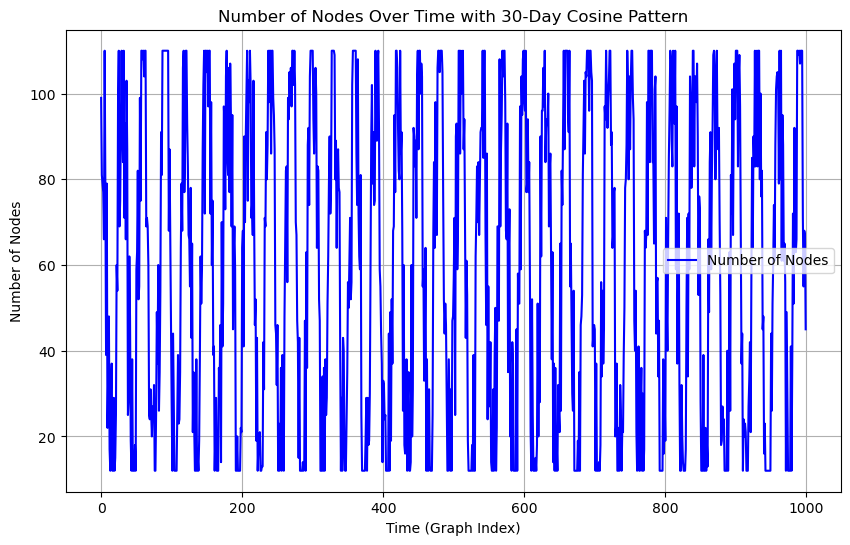

In [2]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

# Function to generate graphs with a cosine cycle pattern for nodes with random edges
def generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size):
    graphs = []
    
    # Cosine pattern with a cycle (adjusted period for nodes)
    node_pattern = (max_nodes / 2) * (1 + np.cos(2 * np.pi * np.arange(num_graphs) / period_days))

    # Create graphs based on the node pattern
    for i in range(num_graphs):
        # Add more randomness to the number of nodes around the cosine pattern to increase variation
        num_nodes = start_size + max(2, min(int(node_pattern[i] + random.uniform(-0.3 * max_nodes, 0.3 * max_nodes)), max_nodes))

        # Create an empty graph with num_nodes
        G = nx.empty_graph(num_nodes)

        # Ensure each node has at least one edge
        for node in G.nodes():
            possible_edges = [edge for edge in nx.non_edges(G) if node in edge]
            if possible_edges:
                selected_edge = random.choice(possible_edges)
                G.add_edge(*selected_edge)
        
        # Randomly add additional edges based on the average number of edges per node
        num_edges = avg_edges_per_node * num_nodes
        possible_edges = list(nx.non_edges(G))
        if num_edges > len(possible_edges):
            num_edges = len(possible_edges)
        selected_edges = np.random.choice(len(possible_edges), int(num_edges), replace=False)
        G.add_edges_from([possible_edges[j] for j in selected_edges])

        # Print the graph details for verification
        print(f"Graph {i}: Nodes = {G.number_of_nodes()}, Edges = {G.number_of_edges()}")
        graphs.append(G)

    return graphs

# Parameters for graph generation
num_graphs = 1000  # Number of graphs for training
max_nodes = 100  # Maximum number of nodes
avg_edges_per_node = 5  # Average number of edges per node
period_days = 30  # Set the period of the cosine cycle
start_size = 10  # Starting size for nodes

# Generate graphs with cosine patterns for nodes and random edges
synthetic_graphs = generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size)

# Optional: Plot the number of nodes over time
node_pattern = (max_nodes / 2) * (1 + np.cos(2 * np.pi * np.arange(num_graphs) / period_days))
num_nodes_with_randomness = [
    start_size + max(2, min(int(n + np.random.uniform(-0.3 * max_nodes, 0.3 * max_nodes)), max_nodes))
    for n in node_pattern
]

plt.figure(figsize=(10, 6))
plt.plot(num_nodes_with_randomness, label="Number of Nodes", color="blue")
plt.title(f"Number of Nodes Over Time with {period_days}-Day Cosine Pattern")
plt.xlabel("Time (Graph Index)")
plt.ylabel("Number of Nodes")
plt.grid(True)
plt.legend()
plt.show()


In [6]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

# Node activation functions for degree-based filtration
def degree_activation(degrees, threshold):
    return {node for node, degree in degrees.items() if degree <= threshold}

# Compute global degree thresholds based on the degree distribution across all graphs
def compute_degree_thresholds(graphs, num_thresholds=10):
    all_degrees = []
    
    # Collect all degrees from all graphs
    for graph in graphs:
        degrees = dict(graph.degree()).values()
        all_degrees.extend(degrees)
    
    # Compute the thresholds based on quantiles of the degree distribution
    thresholds = np.percentile(all_degrees, np.linspace(0, 100, num_thresholds + 1)[1:])
    
    return thresholds

# Filtration function for generating embeddings (20-dimensional active data)
def graph_filtration(graph, metric, activation_func, thresholds):
    active_data = []
    
    for threshold in thresholds:
        active_node_set = activation_func(metric, threshold)
        active_edges = {edge for edge in graph.edges() if edge[0] in active_node_set and edge[1] in active_node_set}
        # Each filtration gives 2 features: (number of active edges, number of active nodes)
        active_data.extend([len(active_node_set), len(active_edges)])  # 2 features per threshold
    
    return active_data  # 20-dimensional vector

# Process the graphs and generate embeddings (each embedding is 20-dimensional)
def process_graphs_for_embeddings(graphs):
    all_embeddings = []
    
    # Compute global thresholds based on all graphs
    thresholds = compute_degree_thresholds(graphs, num_thresholds=10)
    
    for graph in graphs:
        metric = dict(graph.degree())  # Degree centrality as metric
        active_data = graph_filtration(graph, metric, degree_activation, thresholds)
        all_embeddings.append(active_data)  # 20-dimensional embedding
    
    return all_embeddings

# Parameters for graph generation (example from your previous code)
num_graphs = 1000  # Adjust the number of graphs for training
max_nodes = 100  # Maximum number of nodes
avg_edges_per_node = 5  # Average number of edges per node
period_days = 30  # Set the period of the cosine cycle
start_size = 10  # Starting size for nodes

# Generate synthetic graphs with cosine patterns for nodes and random edges
synthetic_graphs = generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size)

# Generate embeddings from synthetic graphs using learned thresholds
embeddings = process_graphs_for_embeddings(synthetic_graphs)


Graph 0: Nodes = 110, Edges = 660
Graph 1: Nodes = 110, Edges = 660
Graph 2: Nodes = 90, Edges = 540
Graph 3: Nodes = 76, Edges = 456
Graph 4: Nodes = 78, Edges = 468
Graph 5: Nodes = 87, Edges = 522
Graph 6: Nodes = 65, Edges = 390
Graph 7: Nodes = 40, Edges = 240
Graph 8: Nodes = 47, Edges = 282
Graph 9: Nodes = 41, Edges = 246
Graph 10: Nodes = 60, Edges = 360
Graph 11: Nodes = 15, Edges = 90
Graph 12: Nodes = 30, Edges = 180
Graph 13: Nodes = 12, Edges = 66
Graph 14: Nodes = 12, Edges = 66
Graph 15: Nodes = 12, Edges = 66
Graph 16: Nodes = 14, Edges = 84
Graph 17: Nodes = 21, Edges = 126
Graph 18: Nodes = 12, Edges = 66
Graph 19: Nodes = 12, Edges = 66
Graph 20: Nodes = 57, Edges = 342
Graph 21: Nodes = 15, Edges = 90
Graph 22: Nodes = 73, Edges = 438
Graph 23: Nodes = 77, Edges = 462
Graph 24: Nodes = 69, Edges = 414
Graph 25: Nodes = 57, Edges = 342
Graph 26: Nodes = 91, Edges = 546
Graph 27: Nodes = 110, Edges = 660
Graph 28: Nodes = 90, Edges = 540
Graph 29: Nodes = 84, Edges =

In [7]:
class LSTMGRUPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMGRUPredictor, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Define LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # Define GRU layer
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True)
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x, hidden=None):
        # If hidden state is not provided, initialize it to zeros
        if hidden is None:
            h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)  # LSTM hidden state
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)  # LSTM cell state
        else:
            h0, c0 = hidden  # Unpack the hidden state
        
        # Forward pass through LSTM
        lstm_out, (h0, c0) = self.lstm(x, (h0, c0))
        
        # Forward pass through GRU (use LSTM output as input)
        gru_out, h0 = self.gru(lstm_out, h0)
        
        # Fully connected layer on the final hidden state
        out = self.fc(gru_out[:, -1, :])  # Take the last output from the sequence
        return out, (h0, c0)


In [11]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Assuming 'embeddings' is the full data you are working with
# Split the embeddings into training and test sets (80% train, 20% test)
train_embeddings, test_embeddings = train_test_split(embeddings, test_size=0.2, shuffle=False)

# Dataset class for embeddings with flexibility for both train and test sets
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = embeddings
    
    def __len__(self):
        return len(self.embeddings) - 1  # We want to predict the next embedding
    
    def __getitem__(self, idx):
        x = torch.Tensor(self.embeddings[idx]).unsqueeze(0)  # Add sequence dimension
        y = torch.Tensor(self.embeddings[idx + 1])  # Next embedding as target
        return x, y

# Create training and testing datasets and loaders
train_dataset = EmbeddingDataset(train_embeddings)
test_dataset = EmbeddingDataset(test_embeddings)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)  
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# LSTM + GRU model parameters
input_dim = 20  # 20-dimensional embeddings
hidden_dim = 128
output_dim = 20  # Predict the next 20-dimensional embedding
num_layers = 2

# Define the model (assuming LSTMGRUPredictor is defined elsewhere)
model = LSTMGRUPredictor(input_dim, hidden_dim, output_dim, num_layers)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Function to train the model with proper hidden state management
def train_model():
    model.train()
    epoch_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        
        # Reset hidden state at the start of each sequence (batch)
        hidden = None
        output, hidden = model(x, hidden)
        
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(train_loader)

# Training loop
num_epochs = 500
for epoch in range(num_epochs):
    loss = train_model()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss}")

# Set the starting index for the test set
split_index = len(train_embeddings)  # The start of the test set time index

# Evaluation on test set with hidden state management
model.eval()
test_loss = 0
time_index = split_index  # Start time index at the beginning of the test set
with torch.no_grad():
    hidden = None  # Initialize hidden state
    for x, y in test_loader:
        output, hidden = model(x, hidden)  # Maintain hidden state across time steps
        loss = criterion(output, y)
        test_loss += loss.item()
        
        # Print time index, predicted embedding, and real embedding
        for i in range(len(x)):
            predicted_embedding = output[i].numpy()
            real_embedding = y[i].numpy()
            print(f"Time Index: {time_index}")
            print(f"Predicted Embedding: {predicted_embedding}")
            print(f"Real Embedding: {real_embedding}")
            print("-" * 50)
            time_index += 1

print(f"Test Loss: {test_loss/len(test_loader)}")


Epoch 1/500, Loss: 19818.2005078125
Epoch 2/500, Loss: 18624.97814453125
Epoch 3/500, Loss: 17715.75625
Epoch 4/500, Loss: 16924.899453125
Epoch 5/500, Loss: 16213.023916015625
Epoch 6/500, Loss: 15562.346870117188
Epoch 7/500, Loss: 14962.164731445313
Epoch 8/500, Loss: 14404.9864453125
Epoch 9/500, Loss: 13885.162114257813
Epoch 10/500, Loss: 13398.275942382812
Epoch 11/500, Loss: 12940.81251953125
Epoch 12/500, Loss: 12509.93310546875
Epoch 13/500, Loss: 12103.313876953125
Epoch 14/500, Loss: 11719.021240234375
Epoch 15/500, Loss: 11355.419965820312
Epoch 16/500, Loss: 11011.10009765625
Epoch 17/500, Loss: 10684.8264453125
Epoch 18/500, Loss: 10375.497368164062
Epoch 19/500, Loss: 10082.1178125
Epoch 20/500, Loss: 9803.780493164062
Epoch 21/500, Loss: 9539.648286132813
Epoch 22/500, Loss: 9288.946865234375
Epoch 23/500, Loss: 9050.954479980468
Epoch 24/500, Loss: 8824.996694335938
Epoch 25/500, Loss: 8610.441640625
Epoch 26/500, Loss: 8406.69586669922
Epoch 27/500, Loss: 8213.201489

RuntimeError: Expected hidden[0] size (2, 7, 128), got [2, 16, 128]

In [36]:
print(y)

tensor([[486.,  81., 486.,  81., 486.,  81., 486.,  81., 486.,  81., 481.,  80.,
         475.,  79., 440.,  74., 424.,  72., 382.,  67.],
        [588.,  98., 588.,  98., 588.,  98., 588.,  98., 584.,  97., 584.,  97.,
         584.,  97., 557.,  93., 487.,  84., 420.,  76.],
        [648., 108., 648., 108., 648., 108., 648., 108., 648., 108., 648., 108.,
         642., 107., 593., 100., 547.,  94., 471.,  85.],
        [240.,  40., 240.,  40., 240.,  40., 240.,  40., 240.,  40., 240.,  40.,
         234.,  39., 234.,  39., 226.,  38., 175.,  32.],
        [144.,  24., 144.,  24., 144.,  24., 144.,  24., 144.,  24., 144.,  24.,
         144.,  24., 144.,  24., 144.,  24., 126.,  22.],
        [174.,  29., 174.,  29., 174.,  29., 174.,  29., 174.,  29., 174.,  29.,
         174.,  29., 174.,  29., 158.,  27., 133.,  24.],
        [408.,  68., 408.,  68., 408.,  68., 408.,  68., 408.,  68., 398.,  66.,
         386.,  64., 379.,  63., 340.,  58., 315.,  55.]])
